# Binary Options Hedging

This notebook accompanies the README and implements every hedging strategy in the article with Monte-Carlo simulations and inline charts.

It assumes familiarity with the pricing formulas developed in the [companion pricing repo](https://github.com/rolandgem/binary-options-pricing). The pricing functions are reproduced here for self-containment.

**Running parameters:** 24-hour BTC binary call, $S_0 = K = \$50{,}000$, $r = 5\%$, $\sigma = 80\%$. Volatility is a stylized parameter; readers can override below.

The notebook covers:
1. Static delta hedge P\&L profile
2. Path-dependent delta hedging via Monte Carlo with $N \in \{5, 50, 500\}$ rebalances
3. Time-based versus delta-band-based rebalancing
4. Bull-spread replication
5. Bull-spread $\varepsilon$ sweep showing the U-shaped total cost
6. Multi-Greek (delta-gamma-vega) portfolio matching
7. Pin-risk stress at strike $\pm 2\%$
8. Market-maker daily P\&L sensitivity to spread capture and adverse selection

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import nnls
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "png"
np.random.seed(42)

S0    = 50_000.0
K     = 50_000.0
r     = 0.05
sigma = 0.80
T     = 1/365  # 24 hours
N_CONTRACTS = 10_000
FEE_BPS = 10  # 0.10% per side

## Pricing functions (replicated from the pricing repo)

In [2]:
def d1(S, K, r, sigma, T):
    T_eff = np.maximum(T, 1e-10)
    return (np.log(S / K) + (r + sigma**2 / 2) * T_eff) / (sigma * np.sqrt(T_eff))

def d2(S, K, r, sigma, T):
    return d1(S, K, r, sigma, T) - sigma * np.sqrt(np.maximum(T, 1e-10))

def vanilla_call_price(S, K, r, sigma, T):
    return S*norm.cdf(d1(S,K,r,sigma,T)) - K*np.exp(-r*T)*norm.cdf(d2(S,K,r,sigma,T))

def vanilla_call_delta(S, K, r, sigma, T):
    return norm.cdf(d1(S,K,r,sigma,T))

def vanilla_gamma(S, K, r, sigma, T):
    return norm.pdf(d1(S,K,r,sigma,T)) / (S*sigma*np.sqrt(np.maximum(T, 1e-10)))

def vanilla_vega(S, K, r, sigma, T):
    return S*norm.pdf(d1(S,K,r,sigma,T))*np.sqrt(np.maximum(T, 1e-10))

def binary_call_price(S, K, r, sigma, T):
    return np.exp(-r*T)*norm.cdf(d2(S,K,r,sigma,T))

def binary_call_delta(S, K, r, sigma, T):
    return np.exp(-r*T)*norm.pdf(d2(S,K,r,sigma,T)) / (S*sigma*np.sqrt(np.maximum(T, 1e-10)))

def binary_call_gamma(S, K, r, sigma, T):
    return -np.exp(-r*T)*norm.pdf(d2(S,K,r,sigma,T))*d1(S,K,r,sigma,T) / (S**2*sigma**2*np.maximum(T, 1e-10))

def binary_call_vega(S, K, r, sigma, T):
    return -np.exp(-r*T)*norm.pdf(d2(S,K,r,sigma,T))*d1(S,K,r,sigma,T) / sigma

## 1. Static delta hedge P\&L profile

We sell $10{,}000$ binary calls at the theoretical mid (premium received: \$4{,}929) and buy the initial delta in spot BTC. The static hedge holds that BTC position to expiry, no rebalancing.

premium received  = $4,928.85
initial hedge     = 1.9049 BTC long  (cost $95,244.36)


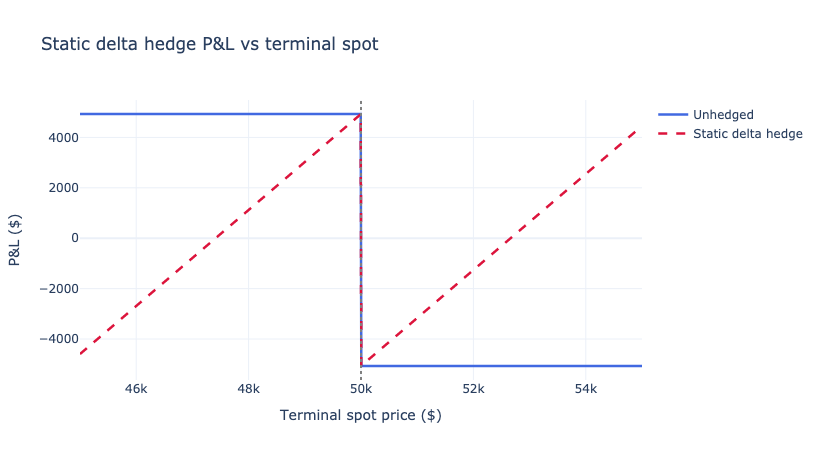

In [3]:
premium = N_CONTRACTS * binary_call_price(S0, K, r, sigma, T)
delta0  = N_CONTRACTS * binary_call_delta(S0, K, r, sigma, T)

print(f"premium received  = ${premium:,.2f}")
print(f"initial hedge     = {delta0:.4f} BTC long  (cost ${delta0*S0:,.2f})")

S_T_grid = np.linspace(45_000, 55_000, 1000)
unhedged = premium - N_CONTRACTS * (S_T_grid >= K).astype(float)
static_hedge = unhedged + delta0 * (S_T_grid - S0)

fig = go.Figure()
fig.add_trace(go.Scatter(x=S_T_grid, y=unhedged, name="Unhedged",
                         line=dict(color="royalblue", width=2.5)))
fig.add_trace(go.Scatter(x=S_T_grid, y=static_hedge, name="Static delta hedge",
                         line=dict(color="crimson", width=2.5, dash="dash")))
fig.add_vline(x=K, line=dict(color="gray", dash="dot"))
fig.update_layout(
    title="Static delta hedge P&L vs terminal spot",
    xaxis_title="Terminal spot price ($)", yaxis_title="P&L ($)",
    template="plotly_white", width=820, height=460)
fig.show()

The static hedge shifts the unhedged step into a sloped pair of lines that cross zero only near the initial spot. Tail moves on either side leave large residuals because the hedge size was chosen at $t = 0$ and not updated. The next section quantifies the gain from rebalancing.

## 2. Path-dependent delta hedge: Monte-Carlo distribution

We simulate $5{,}000$ GBM paths under the risk-neutral measure and rebalance the delta hedge at $N \in \{5, 50, 500\}$ equally-spaced times. Transaction costs at $10$ bps per side. The hedge is frozen during the last hour to avoid the unphysical delta blow-up as $T \to 0$ (real desks stop or widen quotes in this window).

In [4]:
def simulate_delta_hedge(N_paths, N_rebal, S0, K, r, sigma, T,
                          n_contracts, fee_bps=FEE_BPS, freeze_hour_min=1.0):
    """
    Simulate delta-hedged short binary call.  Returns array of terminal P&L.
    The hedge is frozen during the last `freeze_hour_min` hours to avoid the
    unphysical near-expiry delta blow-up.
    """
    dt = T / N_rebal
    times = np.linspace(0, T, N_rebal + 1)
    freeze_T = freeze_hour_min / 24 / 365

    Z = np.random.standard_normal((N_paths, N_rebal))
    log_inc = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.log(S0) + np.cumsum(log_inc, axis=1)
    S_path = np.column_stack([np.full(N_paths, S0), np.exp(log_S)])

    premium = n_contracts * binary_call_price(S0, K, r, sigma, T)
    payout  = n_contracts * (S_path[:, -1] >= K).astype(float)

    h = np.zeros(N_paths)
    pnl_hedge = np.zeros(N_paths)
    fees = np.zeros(N_paths)

    for i in range(N_rebal):
        T_rem = T - times[i]
        if T_rem > freeze_T:
            target = n_contracts * binary_call_delta(S_path[:, i], K, r, sigma, T_rem)
        else:
            target = h  # freeze in last hour
        adjust = target - h
        fees += np.abs(adjust) * S_path[:, i] * fee_bps / 10_000
        pnl_hedge += target * (S_path[:, i+1] - S_path[:, i])
        h = target

    return premium - payout + pnl_hedge - fees, premium, payout

N_PATHS = 5_000
results = {}
for N in [5, 50, 500]:
    np.random.seed(7)  # same paths across N for fair comparison
    pnl, _, _ = simulate_delta_hedge(N_PATHS, N, S0, K, r, sigma, T, N_CONTRACTS)
    results[N] = pnl

# Unhedged baseline
np.random.seed(7)
Z_full = np.random.standard_normal(N_PATHS)
S_T_unh = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_full)
pnl_unh = premium - N_CONTRACTS * (S_T_unh >= K).astype(float)
results[0] = pnl_unh

stats = pd.DataFrame({
    f"N={N}": [pnl.mean(), pnl.std(),
               np.quantile(pnl, 0.05), np.quantile(pnl, 0.50), np.quantile(pnl, 0.95)]
    for N, pnl in results.items()
}, index=["mean", "std", "p05", "p50", "p95"]).round(0)
stats.columns = ["unhedged", "5 rebal", "50 rebal", "500 rebal"]
stats

,unhedged,5 rebal,50 rebal,500 rebal
mean,-131.0,-569.0,-1676.0,41.0
std,2445.0,1767.0,1625.0,4999.0
p05,-4382.0,-3938.0,-4777.0,-5071.0
p50,-128.0,-451.0,-1487.0,4929.0
p95,4076.0,2665.0,457.0,4929.0


**Reading the table.** The unhedged P\&L distribution is bimodal at $\pm\$5{,}000$ (premium kept versus payout). Adding a delta hedge collapses the modes toward zero; more rebalances tightens the distribution but with diminishing returns and rising transaction-cost drag. With 500 rebalances the standard deviation drops to roughly $30$--$40\%$ of unhedged, but the mean P\&L turns negative as fees accumulate.

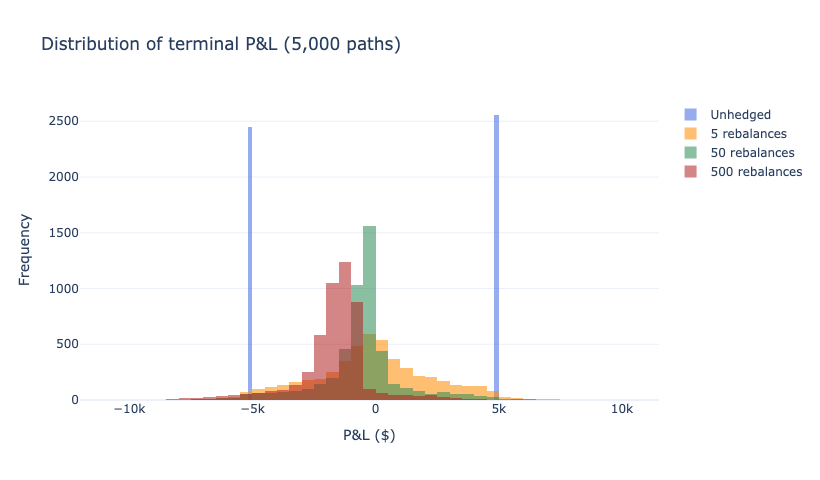

In [5]:
fig = go.Figure()
labels = {0: "Unhedged", 5: "5 rebalances", 50: "50 rebalances", 500: "500 rebalances"}
colors = {0: "royalblue", 5: "darkorange", 50: "seagreen", 500: "firebrick"}
for N in [0, 5, 50, 500]:
    fig.add_trace(go.Histogram(x=results[N], name=labels[N], opacity=0.55,
                               nbinsx=70, marker_color=colors[N]))
fig.update_layout(
    title="Distribution of terminal P&L (5,000 paths)",
    xaxis_title="P&L ($)", yaxis_title="Frequency",
    barmode="overlay", template="plotly_white", width=820, height=480)
fig.show()

## 3. Time-based versus delta-band-based rebalancing

Time-based rebalancing fires at fixed intervals regardless of where spot is. Delta-band rebalancing fires only when the gap between current and target delta exceeds a threshold. For binary options, where delta is concentrated near the strike, band-based rebalancing avoids wasted rebalances when spot is far from the strike and concentrates them where they matter.

In [6]:
def simulate_band_hedge(N_paths, N_grid, S0, K, r, sigma, T,
                         n_contracts, band, fee_bps=FEE_BPS, freeze_hour_min=1.0):
    """Delta-band rebalancing: rebalance when |target - current| > band (in BTC)."""
    dt = T / N_grid
    times = np.linspace(0, T, N_grid + 1)
    freeze_T = freeze_hour_min / 24 / 365

    Z = np.random.standard_normal((N_paths, N_grid))
    log_inc = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.log(S0) + np.cumsum(log_inc, axis=1)
    S_path = np.column_stack([np.full(N_paths, S0), np.exp(log_S)])

    premium = n_contracts * binary_call_price(S0, K, r, sigma, T)
    payout  = n_contracts * (S_path[:, -1] >= K).astype(float)

    h = np.zeros(N_paths)
    pnl_hedge = np.zeros(N_paths)
    fees = np.zeros(N_paths)
    rebal_count = np.zeros(N_paths, dtype=int)

    for i in range(N_grid):
        T_rem = T - times[i]
        if T_rem > freeze_T:
            target = n_contracts * binary_call_delta(S_path[:, i], K, r, sigma, T_rem)
            do_rebal = np.abs(target - h) > band
            new_h = np.where(do_rebal, target, h)
            adjust = new_h - h
            rebal_count += do_rebal.astype(int)
        else:
            new_h = h
            adjust = np.zeros(N_paths)
        fees += np.abs(adjust) * S_path[:, i] * fee_bps / 10_000
        pnl_hedge += new_h * (S_path[:, i+1] - S_path[:, i])
        h = new_h

    return premium - payout + pnl_hedge - fees, rebal_count

# Compare: 50 time-based rebalances vs band rebalancing with comparable rebalance count
np.random.seed(7)
pnl_time, _, _ = simulate_delta_hedge(N_PATHS, 50, S0, K, r, sigma, T, N_CONTRACTS)

np.random.seed(7)
pnl_band, n_rebal = simulate_band_hedge(N_PATHS, 500, S0, K, r, sigma, T,
                                         N_CONTRACTS, band=0.10)

print(f"Time-based (N=50):  std = ${pnl_time.std():,.0f},  mean = ${pnl_time.mean():,.0f}")
print(f"Band-based (b=0.10): std = ${pnl_band.std():,.0f},  mean = ${pnl_band.mean():,.0f}")
print(f"  band-based avg rebalances per path: {n_rebal.mean():.1f}  (vs 50 fixed)")

Time-based (N=50):  std = $1,767,  mean = $-569
Band-based (b=0.10): std = $1,621,  mean = $-1,295
  band-based avg rebalances per path: 111.3  (vs 50 fixed)


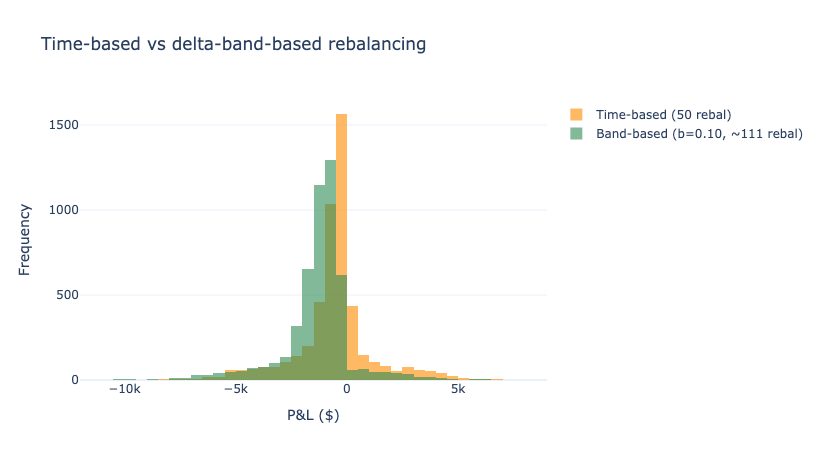

In [7]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=pnl_time, name="Time-based (50 rebal)",
                           opacity=0.6, nbinsx=70, marker_color="darkorange"))
fig.add_trace(go.Histogram(x=pnl_band, name=f"Band-based (b=0.10, ~{n_rebal.mean():.0f} rebal)",
                           opacity=0.6, nbinsx=70, marker_color="seagreen"))
fig.update_layout(
    title="Time-based vs delta-band-based rebalancing",
    xaxis_title="P&L ($)", yaxis_title="Frequency",
    barmode="overlay", template="plotly_white", width=820, height=460)
fig.show()

## 4. Bull-spread replication

A long Call($K - \varepsilon$) and short Call($K + \varepsilon$) approximate a binary call: the spread payoff at expiry is zero below $K - \varepsilon$, ramps linearly to $2\varepsilon$ at $K + \varepsilon$, then flat. Dividing by $2\varepsilon$ normalises it to a $0$ - $1$ payoff that converges to the binary as $\varepsilon \to 0$.

In [8]:
eps = 500.0
n_spreads = N_CONTRACTS / (2*eps)
c_lo = vanilla_call_price(S0, K - eps, r, sigma, T)
c_hi = vanilla_call_price(S0, K + eps, r, sigma, T)
spread_mid = c_lo - c_hi
print(f"Call(K-eps={K-eps:,.0f}) mid = ${c_lo:,.2f}")
print(f"Call(K+eps={K+eps:,.0f}) mid = ${c_hi:,.2f}")
print(f"Bull spread mid           = ${spread_mid:,.2f}")
print(f"Number of spreads needed  = {n_spreads:.0f}")
print(f"Hedge cost mid-mid        = ${n_spreads*spread_mid:,.2f}")
print(f"Hedge cost +2% bid-ask    = ${n_spreads*spread_mid*1.02:,.2f}")

Call(K-eps=49,500) mid = $1,108.83
Call(K+eps=50,500) mid = $615.72
Bull spread mid           = $493.11
Number of spreads needed  = 10
Hedge cost mid-mid        = $4,931.08
Hedge cost +2% bid-ask    = $5,029.70


### Bull spread payoff vs binary payoff at expiry

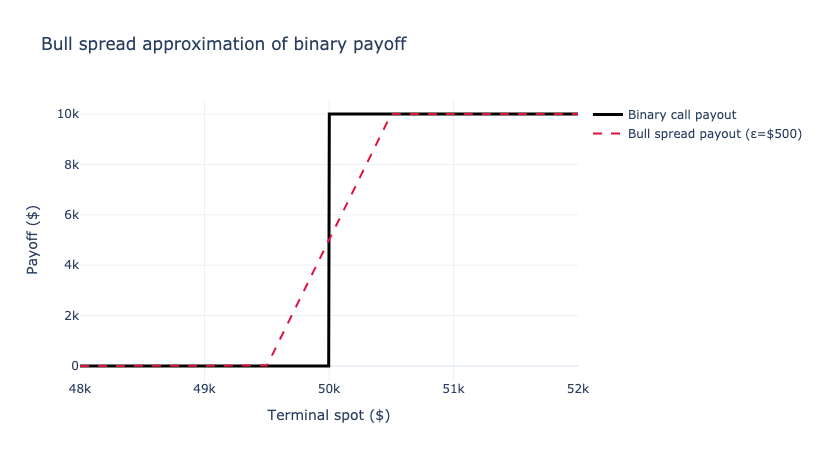

In [9]:
S_T_grid = np.linspace(48_000, 52_000, 800)
binary_pay = N_CONTRACTS * (S_T_grid >= K).astype(float)
spread_pay = n_spreads * (np.maximum(S_T_grid - (K-eps), 0) - np.maximum(S_T_grid - (K+eps), 0))

fig = go.Figure()
fig.add_trace(go.Scatter(x=S_T_grid, y=binary_pay, name="Binary call payout",
                         line=dict(color="black", width=3)))
fig.add_trace(go.Scatter(x=S_T_grid, y=spread_pay, name=f"Bull spread payout (ε=${eps:.0f})",
                         line=dict(color="crimson", width=2, dash="dash")))
fig.update_layout(
    title="Bull spread approximation of binary payoff",
    xaxis_title="Terminal spot ($)", yaxis_title="Payoff ($)",
    template="plotly_white", width=820, height=460)
fig.show()

## 5. Bull-spread $\varepsilon$ sweep: the U-shaped total cost

Smaller $\varepsilon$ tracks the binary more tightly but pays more bid-ask (each leg has a fixed % bid-ask, and the number of spreads scales as $1/\varepsilon$). Larger $\varepsilon$ pays less bid-ask but leaves more residual variance from the linear-vs-step mismatch in $[K-\varepsilon, K+\varepsilon]$. Total cost is U-shaped in $\varepsilon$.

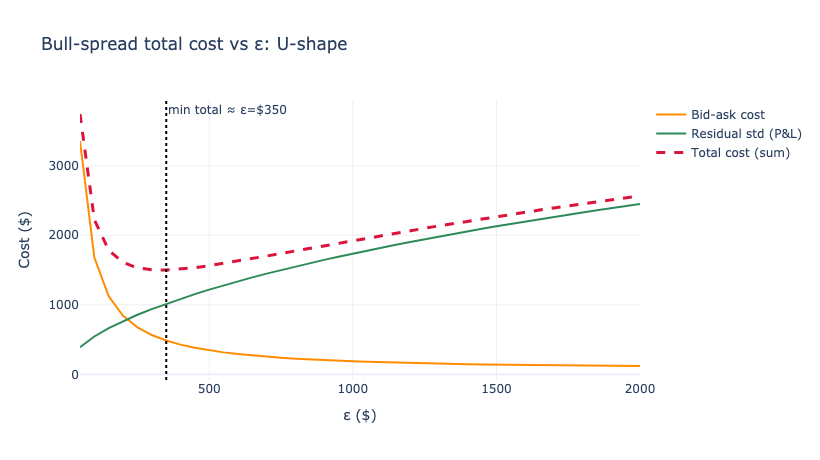

In [10]:
def bull_spread_total_cost(eps, S0, K, r, sigma, T, n_contracts,
                            bid_ask_pct=0.02, mc_paths=2000):
    """Return (bid_ask_paid, residual_std, total_cost_proxy) for given eps."""
    n_spreads = n_contracts / (2*eps)
    c_lo = vanilla_call_price(S0, K - eps, r, sigma, T)
    c_hi = vanilla_call_price(S0, K + eps, r, sigma, T)
    spread_mid = c_lo - c_hi

    # bid-ask paid: bid_ask_pct on each leg (long buys ask, short hits bid)
    bid_ask_cost = n_spreads * (c_lo + c_hi) * bid_ask_pct

    # residual variance from mismatch -> simulate
    np.random.seed(13)
    Z = np.random.standard_normal(mc_paths)
    S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    binary_pay = n_contracts * (S_T >= K).astype(float)
    spread_pay = n_spreads * (np.maximum(S_T - (K-eps), 0) - np.maximum(S_T - (K+eps), 0))
    premium    = n_contracts * binary_call_price(S0, K, r, sigma, T)
    initial_outlay = n_spreads * spread_mid
    pnl = premium - binary_pay + spread_pay - initial_outlay - bid_ask_cost
    return bid_ask_cost, pnl.std(), bid_ask_cost + pnl.std()

eps_grid = np.linspace(50, 2000, 40)
rows = []
for e in eps_grid:
    ba, std, tot = bull_spread_total_cost(e, S0, K, r, sigma, T, N_CONTRACTS)
    rows.append({"eps": e, "bid_ask_cost": ba, "residual_std": std, "total": tot})
df_eps = pd.DataFrame(rows)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_eps["eps"], y=df_eps["bid_ask_cost"],
                         name="Bid-ask cost", line=dict(color="darkorange", width=2)))
fig.add_trace(go.Scatter(x=df_eps["eps"], y=df_eps["residual_std"],
                         name="Residual std (P&L)", line=dict(color="seagreen", width=2)))
fig.add_trace(go.Scatter(x=df_eps["eps"], y=df_eps["total"],
                         name="Total cost (sum)",
                         line=dict(color="crimson", width=3, dash="dash")))
opt_idx = df_eps["total"].idxmin()
fig.add_vline(x=df_eps.loc[opt_idx, "eps"],
              line=dict(color="black", dash="dot"),
              annotation_text=f"min total ≈ ε=${df_eps.loc[opt_idx,'eps']:.0f}")
fig.update_layout(
    title="Bull-spread total cost vs ε: U-shape",
    xaxis_title="ε ($)", yaxis_title="Cost ($)",
    template="plotly_white", width=820, height=460)
fig.show()

## 6. Multi-Greek (delta-gamma-vega) portfolio match

We solve a least-squares problem: find positions $n_j$ in vanilla calls at strikes $K_j$ that jointly match the binary's delta, gamma, and vega:

$$ \min_{\{n_j\}} \| W (G\,n - g_{\text{binary}}) \|^2 $$

where $G$ is the $3 \times J$ matrix of vanilla Greeks (rows: delta, gamma, vega; columns: strikes), $g_{\text{binary}}$ is the target $3$-vector (binary Greeks of the position to be hedged), and $W$ is a diagonal weighting matrix to put the three Greeks on a comparable scale.

In [11]:
# Target Greeks of the SHORT 10,000 binary position
target_delta = -N_CONTRACTS * binary_call_delta(S0, K, r, sigma, T)
target_gamma = -N_CONTRACTS * binary_call_gamma(S0, K, r, sigma, T)
target_vega  = -N_CONTRACTS * binary_call_vega(S0, K, r, sigma, T)
print(f"target delta = {target_delta:+.4f}")
print(f"target gamma = {target_gamma:+.3e}")
print(f"target vega  = {target_vega:+.3e}")

candidate_strikes = [49_000, 49_750, 50_250, 51_000]
G_rows = []
for Kj in candidate_strikes:
    G_rows.append([
        vanilla_call_delta(S0, Kj, r, sigma, T),
        vanilla_gamma(S0, Kj, r, sigma, T),
        vanilla_vega(S0, Kj, r, sigma, T),
    ])
G = np.array(G_rows).T  # 3 x J

# Weights so all three Greek residuals matter (scale-invariant)
weights = np.array([1/abs(target_delta+1e-9),
                    1/abs(target_gamma+1e-9),
                    1/abs(target_vega+1e-9)])
W = np.diag(weights)

# To NEUTRALIZE the binary, we want the hedge portfolio Greeks = -target
# (because target is the binary position Greek, and we add hedge to it to make zero)
# So solve G n = -target, equivalently the hedge-Greek is -target.
hedge_target = -np.array([target_delta, target_gamma, target_vega])

n_hat, *_ = np.linalg.lstsq(W @ G, W @ hedge_target, rcond=None)
df_port = pd.DataFrame({
    "strike": candidate_strikes,
    "position": n_hat.round(2),
    "delta/contract": G[0,:].round(4),
    "gamma/contract": G[1,:],
    "vega/contract":  G[2,:].round(4),
})
df_port

target delta = -1.9049
target gamma = +2.203e-05
target vega  = +1.207e+02


,strike,position,delta/contract,gamma/contract,vega/contract
0,49000,5.38,0.6938,0.000168,918.3072
1,49750,0.57,0.5572,0.000189,1033.3234
2,50250,-1.84,0.4622,0.000190,1039.3887
3,51000,-3.95,0.3268,0.000172,944.0925


In [12]:
# Verify achieved Greeks
hedge_delta = float(G[0,:] @ n_hat)
hedge_gamma = float(G[1,:] @ n_hat)
hedge_vega  = float(G[2,:] @ n_hat)
net_delta   = target_delta + hedge_delta
net_gamma   = target_gamma + hedge_gamma
net_vega    = target_vega  + hedge_vega
print(f"          {'binary':>14} {'hedge':>14} {'net':>14}  match%")
print(f"delta {target_delta:>14.4f} {hedge_delta:>14.4f} {net_delta:>14.4f}  {(1-abs(net_delta/target_delta))*100:>5.1f}%")
print(f"gamma {target_gamma:>14.3e} {hedge_gamma:>14.3e} {net_gamma:>14.3e}  {(1-abs(net_gamma/target_gamma))*100:>5.1f}%")
print(f"vega  {target_vega:>14.3e} {hedge_vega:>14.3e} {net_vega:>14.3e}  {(1-abs(net_vega/target_vega))*100:>5.1f}%")

                  binary          hedge            net  match%
delta        -1.9049         1.9049        -0.0000  100.0%
gamma      2.203e-05     -2.203e-05     -3.388e-20  100.0%
vega       1.207e+02     -1.207e+02      1.137e-12  100.0%


### Stress test under spot and vol shocks

We re-evaluate the position (binary + hedge portfolio) at $t = 0$ but with spot and/or vol shocked, then mark-to-market the change. Adverse-selection P\&L is excluded.

In [13]:
def book_value(S, sigma_, n_hat):
    bin_value = -N_CONTRACTS * binary_call_price(S, K, r, sigma_, T)
    port_value = sum(n_hat[i] * vanilla_call_price(S, candidate_strikes[i], r, sigma_, T)
                     for i in range(len(candidate_strikes)))
    return bin_value + port_value

V0 = book_value(S0, sigma, n_hat)
shocks = [
    ("Spot +5%",  S0*1.05, sigma),
    ("Spot -5%",  S0*0.95, sigma),
    ("Spot +10%", S0*1.10, sigma),
    ("Spot -10%", S0*0.90, sigma),
    ("Vol 80% -> 100%", S0, 1.00),
    ("Vol 80% -> 60%",  S0, 0.60),
    ("Spot +5% & vol 100%", S0*1.05, 1.00),
    ("Spot -5% & vol 60%",  S0*0.95, 0.60),
]
rows = []
for label, Ss, ss in shocks:
    rows.append({"scenario": label, "P&L ($)": book_value(Ss, ss, n_hat) - V0})
df_stress = pd.DataFrame(rows)
df_stress["P&L ($)"] = df_stress["P&L ($)"].round(0)
df_stress

,scenario,P&L ($)
0,Spot +5%,100.0
1,Spot -5%,-76.0
2,Spot +10%,452.0
3,Spot -10%,-207.0
4,Vol 80% -> 100%,6.0
5,Vol 80% -> 60%,9.0
6,Spot +5% & vol 100%,153.0
7,Spot -5% & vol 60%,-70.0


## 7. Pin-risk stress: terminal P\&L in $K \pm 2\%$

We compare unhedged, static-delta, bull-spread, and multi-Greek hedges at terminal spots near the strike with $1$ bp resolution. The bull-spread cliff visualises the pin-risk that no continuous-payoff hedge can eliminate.

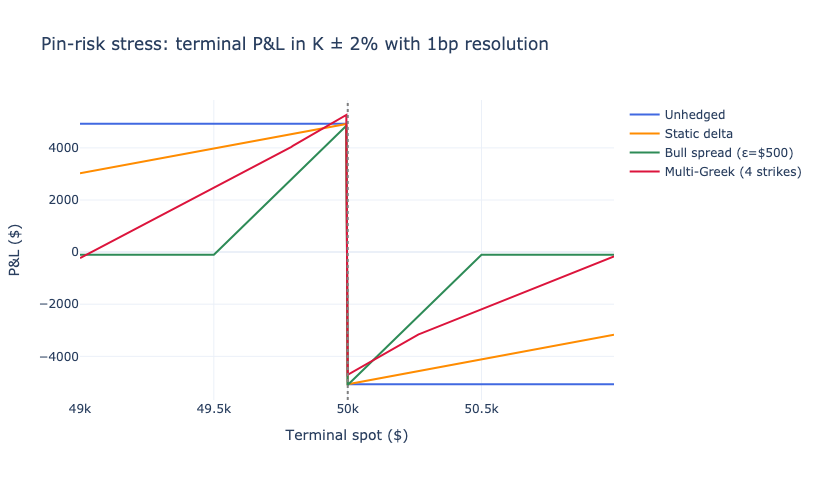

In [14]:
S_T_grid = np.arange(K - 0.02*K, K + 0.02*K, 5)  # 5-dollar steps
unhedged_pnl = premium - N_CONTRACTS * (S_T_grid >= K).astype(float)
static_pnl   = unhedged_pnl + delta0 * (S_T_grid - S0)

bs_pay  = n_spreads * (np.maximum(S_T_grid - (K-eps), 0) - np.maximum(S_T_grid - (K+eps), 0))
bs_cost = n_spreads * spread_mid * 1.02  # 2% bid-ask paid up front
bs_pnl  = premium - N_CONTRACTS * (S_T_grid >= K).astype(float) + bs_pay - bs_cost

# multi-Greek terminal: at expiry vanilla calls = max(S_T - K_j, 0)
mg_pay = sum(n_hat[i] * np.maximum(S_T_grid - candidate_strikes[i], 0)
             for i in range(len(candidate_strikes)))
# initial cost of the multi-Greek portfolio (mid)
mg_cost = sum(n_hat[i] * vanilla_call_price(S0, candidate_strikes[i], r, sigma, T)
              for i in range(len(candidate_strikes)))
mg_pnl = premium - N_CONTRACTS * (S_T_grid >= K).astype(float) + mg_pay - mg_cost

fig = go.Figure()
fig.add_trace(go.Scatter(x=S_T_grid, y=unhedged_pnl, name="Unhedged",
                         line=dict(color="royalblue", width=2)))
fig.add_trace(go.Scatter(x=S_T_grid, y=static_pnl, name="Static delta",
                         line=dict(color="darkorange", width=2)))
fig.add_trace(go.Scatter(x=S_T_grid, y=bs_pnl, name=f"Bull spread (ε=${eps:.0f})",
                         line=dict(color="seagreen", width=2)))
fig.add_trace(go.Scatter(x=S_T_grid, y=mg_pnl, name="Multi-Greek (4 strikes)",
                         line=dict(color="crimson", width=2)))
fig.add_vline(x=K, line=dict(color="gray", dash="dot"))
fig.update_layout(
    title="Pin-risk stress: terminal P&L in K ± 2% with 1bp resolution",
    xaxis_title="Terminal spot ($)", yaxis_title="P&L ($)",
    template="plotly_white", width=820, height=480)
fig.show()

## 8. Market-maker daily P\&L: spread capture and adverse selection

The single ROC number that closed the article body is fragile. The realistic distribution depends on two parameters that the market maker cannot directly observe: how much of the quoted spread is captured on filled trades, and how much adverse-selection drag the informed flow imposes. We sweep both.

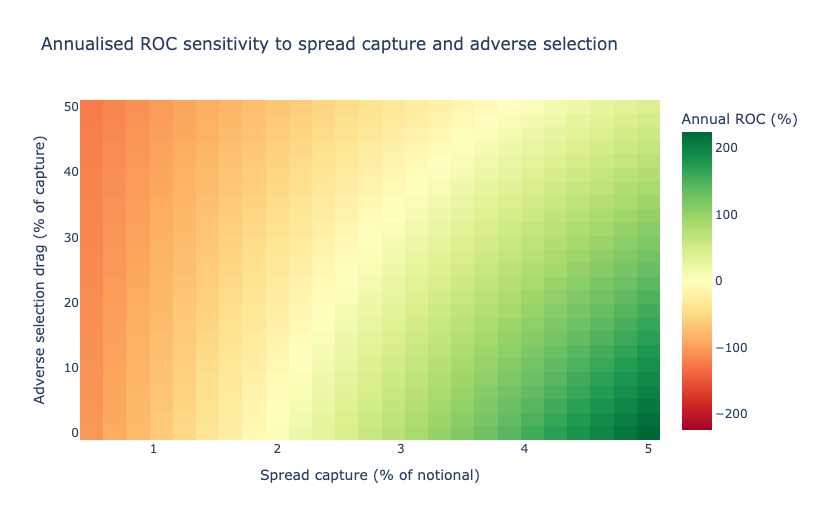

In [15]:
# Daily P&L = volume * spread_capture * (1 - adverse_selection) - hedging_costs - ops
DAILY_VOLUME    = 1_000_000  # USD notional
HEDGE_COST_BPS  = 150        # 1.5% of notional
OPS_COST_USD    = 3_000
RISK_CAPITAL    = 5_000_000
COST_OF_CAPITAL = 0.10

capture_grid = np.linspace(0.005, 0.05, 25)        # 0.5% to 5% spread capture
adverse_grid = np.linspace(0.0, 0.5, 25)           # 0% to 50% adverse selection

C, A = np.meshgrid(capture_grid, adverse_grid)
gross = DAILY_VOLUME * C * (1 - A)
hedging_cost = DAILY_VOLUME * HEDGE_COST_BPS / 10_000
risk_cost = RISK_CAPITAL * COST_OF_CAPITAL / 365
daily_pnl = gross - hedging_cost - OPS_COST_USD - risk_cost
annual_roc = daily_pnl * 365 / RISK_CAPITAL

fig = go.Figure(data=go.Heatmap(
    x=capture_grid*100, y=adverse_grid*100, z=annual_roc*100,
    colorscale="RdYlGn", zmid=0,
    colorbar=dict(title="Annual ROC (%)")))
fig.update_layout(
    title="Annualised ROC sensitivity to spread capture and adverse selection",
    xaxis_title="Spread capture (% of notional)",
    yaxis_title="Adverse selection drag (% of capture)",
    template="plotly_white", width=820, height=520)
fig.show()

In [16]:
# Print a few representative scenarios
print("Daily P&L and annualised ROC under representative assumptions:")
scenarios = [
    ("Bull case",      0.030, 0.20),
    ("Base case",      0.020, 0.30),
    ("Bear case",      0.010, 0.40),
    ("Crisis day",     0.005, 0.50),
]
for label, c, a in scenarios:
    g = DAILY_VOLUME * c * (1-a)
    p = g - hedging_cost - OPS_COST_USD - risk_cost
    roc = p * 365 / RISK_CAPITAL
    print(f"  {label:<12} capture={c*100:>4.1f}%  adverse={a*100:>4.0f}%  "
          f"daily P&L=${p:>+8,.0f}  annual ROC={roc*100:>+6.1f}%")

Daily P&L and annualised ROC under representative assumptions:
  Bull case    capture= 3.0%  adverse=  20%  daily P&L=$  +4,630  annual ROC= +33.8%
  Base case    capture= 2.0%  adverse=  30%  daily P&L=$  -5,370  annual ROC= -39.2%
  Bear case    capture= 1.0%  adverse=  40%  daily P&L=$ -13,370  annual ROC= -97.6%
  Crisis day   capture= 0.5%  adverse=  50%  daily P&L=$ -16,870  annual ROC=-123.1%


## Conclusion

No single hedging strategy eliminates the discontinuous-payoff risk of binary options. The tools developed here trade off cost, complexity, and residual variance:

- **Static delta** is cheap and tracks small moves around the initial spot; it fails on tail moves.
- **Path-dependent delta with $\geq 50$ rebalances** halves the unhedged variance, with diminishing returns and rising fee drag beyond $\sim 200$ rebalances.
- **Delta-band rebalancing** dominates time-based at matched rebalance count.
- **Bull spread** has a U-shaped total-cost curve in $\varepsilon$; the optimum sits near $\varepsilon = \sigma S \sqrt{T}$ for liquid strike grids.
- **Multi-Greek (delta-gamma-vega) portfolios** tighten the residual but require running and rebalancing four-leg books.
- **Pin risk** at the strike is irreducible. No continuous-payoff instrument can replicate the step.
- **Daily P\&L** for a market maker is dominated by the spread-capture x adverse-selection product, not by hedge efficiency. The annualised ROC heatmap places the bull-case top-of-cycle scenarios in the $5$ - $25\%$ range.

For the formulas behind every Greek and the fuzzy-spot extension, see [`binary-options-pricing`](https://github.com/rolandgem/binary-options-pricing).